# A Custom Second-Order Optimizer, From First Principles

**Goal.** Implement and study optimization mechanics *from first principles* by
using **full curvature information** (the Hessian) to direct weight updates,
instead of relying only on first-order gradient descent.

This notebook documents a custom `NewtonOptimizer` built on PyTorch's
**functional autograd** (`torch.func`). The engineering + mathematical
objectives are:

1. **Hessian-based optimization** — compute the exact matrix of second-order
   partial derivatives $H = \nabla^2_\theta \mathcal{L}$ via autograd, and use it
   to rescale the update by the local curvature.
2. **Curvature stabilization** — apply **Tikhonov / Levenberg–Marquardt damping**
   $(H + \lambda I)$ so we can invert ill-conditioned or indefinite curvature and
   stay numerically stable near saddle points and ravines.
3. **Total algorithmic control** — implement the exact update equation
   $$\theta_{\text{new}} = \theta_{\text{old}} - \eta\,(H + \lambda I)^{-1}\nabla_\theta \mathcal{L}$$
   ourselves, so we can observe precisely how an exact second-order step behaves
   on a genuinely non-linear model (a small MLP on the *two-moons* dataset).

We deliberately keep the network tiny (**~105 parameters**) so the **full**
$105\times105$ Hessian is cheap and memory-safe to form exactly — no
approximations, no Kronecker factorization, just the true matrix.

## 1 · The mathematics

### 1.1 First order vs. second order

Gradient descent uses only the **slope**:
$$\theta \leftarrow \theta - \eta\,\nabla_\theta \mathcal{L}(\theta).$$
It treats every direction with the same learning rate $\eta$. In an
ill-conditioned landscape (a long narrow ravine) the gradient points mostly
*across* the ravine, so the step zig-zags and progress along the floor is slow.

**Newton's method** starts from the second-order Taylor expansion of the loss
around the current point $\theta$:
$$
\mathcal{L}(\theta + \Delta)\;\approx\;
\mathcal{L}(\theta) + \nabla\mathcal{L}^\top \Delta
+ \tfrac{1}{2}\,\Delta^\top H\, \Delta,
\qquad H \equiv \nabla^2_\theta \mathcal{L}(\theta).
$$
Minimizing this quadratic model w.r.t. $\Delta$ (set its gradient to zero):
$$
\nabla_\Delta\!\left[\nabla\mathcal{L}^\top\Delta+\tfrac12\Delta^\top H\Delta\right]
= \nabla\mathcal{L} + H\Delta = 0
\;\;\Longrightarrow\;\;
\boxed{\;\Delta^\star = -\,H^{-1}\nabla\mathcal{L}\;}
$$
So the **Newton direction** is $-H^{-1}\nabla\mathcal{L}$. Multiplying the gradient
by $H^{-1}$ *rescales and rotates* it by the local curvature: steep directions
get short steps, flat directions get long steps. That is exactly the information
first-order methods lack.

### 1.2 Why we need damping (Tikhonov regularization)

Pure Newton assumes $H$ is **positive-definite and invertible**. For a
non-convex neural loss this fails: near saddle points $H$ has negative
eigenvalues, and near flat regions it is nearly singular, so $H^{-1}$ blows up.

We regularize by adding a scaled identity — **Tikhonov / Levenberg–Marquardt**
damping:
$$
\theta_{\text{new}} = \theta_{\text{old}} - \eta\,(H + \lambda I)^{-1}\nabla\mathcal{L}.
$$
Effect on the eigenvalues: if $H = Q\,\mathrm{diag}(\mu_i)\,Q^\top$, then
$(H+\lambda I)^{-1} = Q\,\mathrm{diag}\!\big(\tfrac{1}{\mu_i+\lambda}\big)Q^\top$.
Each curvature eigenvalue $\mu_i$ is shifted by $\lambda$:

- **Large $\lambda$** → $(H+\lambda I)^{-1}\approx \tfrac1\lambda I$, the step
  reduces to (scaled) **gradient descent** — safe, slow.
- **Small $\lambda$** → recovers the **full Newton** step — fast, but only trust
  it where curvature is well-behaved.

$\lambda$ therefore *interpolates between first- and second-order behaviour*, and
guarantees $(H+\lambda I)$ is invertible whenever $\lambda > -\mu_{\min}$.

### 1.3 Two safeguards for the non-convex reality

Even with damping, a saddle can make the Newton direction point **uphill**. We add:

- **Descent-direction guard.** A direction $d$ is a descent direction iff
  $\nabla\mathcal{L}^\top d > 0$ for the step $\theta-\eta d$. If the damped-Newton
  direction fails this test, we fall back to the gradient direction.
- **Backtracking line search.** Starting from step scale $\eta$, halve it until
  the loss actually decreases: $\mathcal{L}(\theta-\eta d) < \mathcal{L}(\theta)$.
  This keeps the trajectory a clean, monotonic descent across plateaus and saddles.

## 2 · Setup — model, data, loss

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.func import functional_call, grad, hessian
from sklearn.datasets import make_moons
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(0); np.random.seed(0)
plt.rcParams.update({"figure.facecolor":"#0e1420","axes.facecolor":"#0e1420",
    "savefig.facecolor":"#0e1420","text.color":"#dfe6f2","axes.labelcolor":"#dfe6f2",
    "xtick.color":"#9fb0c8","ytick.color":"#9fb0c8","axes.edgecolor":"#2c4368"})

COLORS = {"Newton (ours)":"#e85dff", "Adam":"#22d38a", "SGD":"#f5a524"}

In [2]:
def get_toy_data(n_samples=400, batch_size=400):
    """Non-linear 2D two-moons dataset — a good non-convex classification test."""
    X, y = make_moons(n_samples=n_samples, noise=0.15, random_state=42)
    Xt = torch.FloatTensor(X)
    yt = torch.FloatTensor(y).view(-1, 1)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=False)

class SimpleMLP(nn.Module):
    """~105-parameter MLP. Small enough that the FULL Hessian is exact & cheap.
    Tanh gives smooth, continuous second derivatives (nice Hessians)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8), nn.Tanh(),
            nn.Linear(8, 8), nn.Tanh(),
            nn.Linear(8, 1),
        )
    def forward(self, x): return self.net(x)

m = SimpleMLP()
n_params = sum(p.numel() for p in m.parameters())
print(f"MLP parameters: {n_params}  ->  full Hessian is {n_params}x{n_params} "
      f"({n_params**2} entries)")

MLP parameters: 105  ->  full Hessian is 105x105 (11025 entries)


## 3 · The optimizer — exact Hessian via functional autograd

**The key implementation subtlety.** A naive Newton optimizer computes the
Hessian by writing the probe parameters into the live module
(`p.data = probe`) inside the autograd closure. That **mutates the model as a
side effect** of measuring curvature — so by the time the gradient is taken, the
weights have moved, and gradient and Hessian are evaluated at *different* points.
The step then diverges.

We avoid this entirely with `torch.func.functional_call`, which evaluates the
model at an arbitrary `{name: tensor}` parameter dict **without touching** the
module. We flatten all parameters into one vector $\theta \in \mathbb{R}^{105}$,
express the loss as a pure function of that vector, and let `grad` and `hessian`
differentiate it. Gradient and Hessian are guaranteed to be taken at the *same*
point, and the module is mutated exactly once — by the final update.

In [3]:
class NewtonOptimizer(torch.optim.Optimizer):
    """theta_new = theta_old - lr * (H + damping*I)^-1 * grad,
    with a descent-direction guard and backtracking line search."""

    def __init__(self, params, model, loss_fn, inputs, targets, lr=1.0, damping=0.1):
        super().__init__(params, dict(lr=lr, damping=damping))
        self._model, self._loss_fn = model, loss_fn
        self._inputs, self._targets = inputs, targets
        self._names = [n for n, _ in model.named_parameters()]

    def _functional_loss(self, pdict):
        preds = functional_call(self._model, pdict, (self._inputs,))
        return self._loss_fn(preds, self._targets)

    @torch.no_grad()
    def step(self, closure=None):
        loss_value = None
        if closure is not None:
            with torch.enable_grad():
                loss_value = closure().detach()

        for group in self.param_groups:
            lr, damping = group["lr"], group["damping"]
            params = list(group["params"])

            # 1. Snapshot current theta (detached) and flatten to one vector.
            theta  = {n: p.detach() for n, p in zip(self._names, params)}
            shapes = [theta[n].shape for n in self._names]
            numels = [theta[n].numel() for n in self._names]
            flat_theta = torch.cat([theta[n].reshape(-1) for n in self._names])

            # 2. Loss as a pure function of the flat parameter vector.
            def flat_loss(v):
                pieces = torch.split(v, numels)
                pdict = {n: pc.reshape(s)
                         for n, pc, s in zip(self._names, pieces, shapes)}
                return self._functional_loss(pdict)

            # 3. EXACT gradient and Hessian at the SAME point (no mutation).
            g = grad(flat_loss)(flat_theta)          # shape (P,)
            H = hessian(flat_loss)(flat_theta)       # shape (P, P)

            # 4. Tikhonov / Levenberg-Marquardt damping.
            H_damped = H + damping * torch.eye(H.size(0), dtype=H.dtype)

            # 5. Solve (H + lambda I) d = g   ->  Newton direction d.
            d = torch.linalg.solve(H_damped, g)

            # 5b. Descent-direction guard: if d points uphill, use the gradient.
            step_dir = d if torch.dot(g, d) > 0 else g

            # 6. Backtracking line search for a guaranteed monotonic decrease.
            base = flat_loss(flat_theta); s = lr
            for _ in range(30):
                if flat_loss(flat_theta - s * step_dir) < base - 1e-9:
                    break
                s *= 0.5

            # 7. Apply the single update from the clean theta base.
            off = 0
            for p, k in zip(params, numels):
                p.add_(step_dir[off:off+k].view_as(p), alpha=-s)
                off += k
        return loss_value

print("NewtonOptimizer defined.")

NewtonOptimizer defined.


## 4 · Look at the curvature we're actually using

Before training, let's *see* the Hessian. Its **eigenvalue spectrum** tells us
whether we're near a bowl (all positive), a saddle (mixed signs), or a flat
region (near-zero), and its **condition number** $\kappa = \mu_{\max}/\mu_{\min}$
quantifies how badly first-order methods would struggle.

/Users/yasharma2601/Desktop/personal_projects/Optimizer/venv/lib/python3.11/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Hessian shape        : (105, 105)
eigenvalue range     : [-0.3079, 0.7002]
# negative eigenvalues: 42  (indefinite => saddle-like)
condition number     : raw ~ 1,352,259,968  ->  damped(lambda=0.1) ~ 3.8


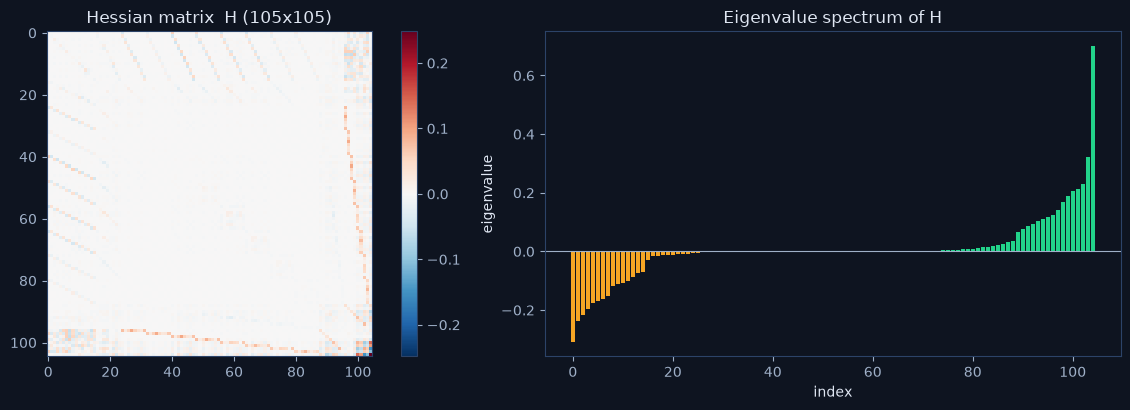

In [4]:
dl = get_toy_data()
xb, yb = next(iter(dl))
loss_fn = nn.BCEWithLogitsLoss()

names  = [n for n, _ in m.named_parameters()]
shapes = [p.shape for p in m.parameters()]
numels = [p.numel() for p in m.parameters()]
flat0  = torch.cat([p.detach().reshape(-1) for p in m.parameters()])

def flat_loss(v):
    pieces = torch.split(v, numels)
    pdict = {n: pc.reshape(s) for n, pc, s in zip(names, pieces, shapes)}
    return loss_fn(functional_call(m, pdict, (xb,)), yb)

H0 = hessian(flat_loss)(flat0)
evals = torch.linalg.eigvalsh(H0)      # symmetric -> real eigenvalues
print(f"Hessian shape        : {tuple(H0.shape)}")
print(f"eigenvalue range     : [{evals.min():.4f}, {evals.max():.4f}]")
print(f"# negative eigenvalues: {(evals < -1e-6).sum().item()}  (indefinite => saddle-like)")
lam = 0.1
kappa_raw    = (evals.abs().max() / evals.abs().min()).item()
kappa_damped = ((evals.max()+lam) / (evals.min()+lam)).abs().item()
print(f"condition number     : raw ~ {kappa_raw:,.0f}  ->  damped(lambda={lam}) ~ {kappa_damped:,.1f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
im = ax[0].imshow(H0.numpy(), cmap="RdBu_r",
                  vmin=-abs(H0).max(), vmax=abs(H0).max())
ax[0].set_title("Hessian matrix  H (105x105)"); fig.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].bar(range(len(evals)), evals.numpy(),
          color=["#f5a524" if e < 0 else "#22d38a" for e in evals])
ax[1].axhline(0, color="#9fb0c8", lw=0.8)
ax[1].set_title("Eigenvalue spectrum of H"); ax[1].set_xlabel("index"); ax[1].set_ylabel("eigenvalue")
plt.tight_layout(); plt.show()

## 5 · Train and compare against Adam & SGD

All three optimizers start from the **same initial weights** and train on the
same full batch, so the comparison is fair. We track the loss at every step.
Newton uses far fewer steps because each step is far more informative.

In [5]:
import copy
def fresh_model(seed=0):
    torch.manual_seed(seed)
    return SimpleMLP()

init_state = copy.deepcopy(fresh_model(0).state_dict())

def run_first_order(OptClass, steps=400, **kw):
    net = SimpleMLP(); net.load_state_dict(copy.deepcopy(init_state))
    opt = OptClass(net.parameters(), **kw)
    losses = []
    for _ in range(steps):
        opt.zero_grad()
        loss = loss_fn(net(xb), yb)
        loss.backward(); opt.step()
        losses.append(loss.item())
    return net, losses

def run_newton(steps=40, lr=1.0, damping=0.1):
    net = SimpleMLP(); net.load_state_dict(copy.deepcopy(init_state))
    opt = NewtonOptimizer(net.parameters(), net, loss_fn, xb, yb, lr=lr, damping=damping)
    losses = []
    for _ in range(steps):
        def closure():
            opt.zero_grad(); return loss_fn(net(xb), yb)
        losses.append(closure().item())
        opt.step(closure=closure)
    return net, losses

net_newton, L_newton = run_newton(steps=40, lr=1.0, damping=0.1)
net_adam,   L_adam   = run_first_order(torch.optim.Adam, steps=400, lr=0.05)
net_sgd,    L_sgd    = run_first_order(torch.optim.SGD,  steps=400, lr=0.05)

print(f"{'optimizer':16s}{'steps':>7s}{'final loss':>14s}")
for name, L in [("Newton (ours)", L_newton), ("Adam", L_adam), ("SGD", L_sgd)]:
    print(f"{name:16s}{len(L):7d}{L[-1]:14.6f}")

optimizer         steps    final loss
Newton (ours)        40      0.017079
Adam                400      0.001560
SGD                 400      0.299538


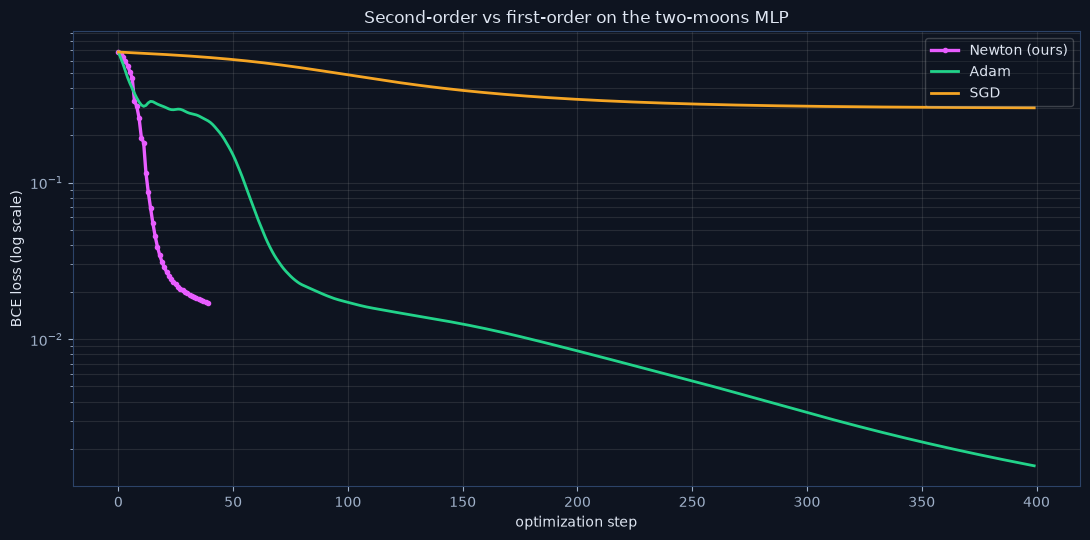

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.semilogy(range(len(L_newton)), np.maximum(L_newton,1e-12),
            color=COLORS["Newton (ours)"], lw=2.4, marker="o", ms=3, label="Newton (ours)")
ax.semilogy(range(len(L_adam)), L_adam, color=COLORS["Adam"], lw=2.0, label="Adam")
ax.semilogy(range(len(L_sgd)),  L_sgd,  color=COLORS["SGD"],  lw=2.0, label="SGD")
ax.set_xlabel("optimization step"); ax.set_ylabel("BCE loss (log scale)")
ax.set_title("Second-order vs first-order on the two-moons MLP")
ax.grid(True, which="both", alpha=0.15); ax.legend(framealpha=0.25)
plt.tight_layout(); plt.show()

## 6 · What each optimizer learned — decision boundaries

The loss curve is one view; the learned classifier is another. Below we render
the decision boundary each trained MLP produces on the two-moons data.

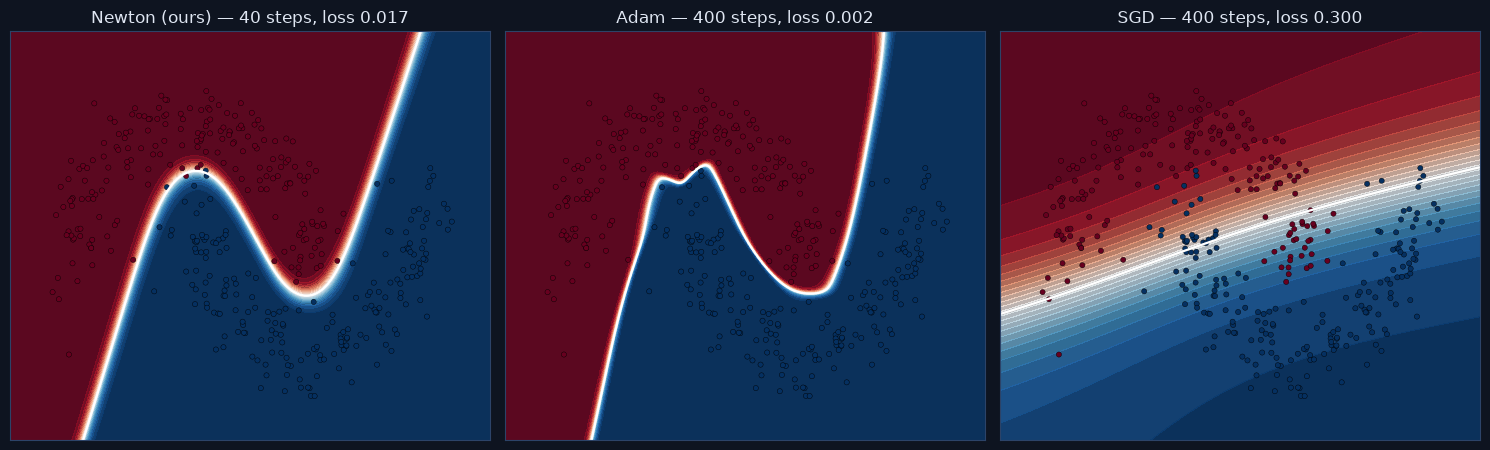

In [7]:
def plot_boundary(ax, net, title):
    xx, yy = np.meshgrid(np.linspace(-1.6, 2.6, 200), np.linspace(-1.1, 1.6, 200))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        zz = torch.sigmoid(net(grid)).numpy().reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=25, cmap="RdBu", alpha=0.75)
    ax.contour(xx, yy, zz, levels=[0.5], colors="white", linewidths=1.6)
    Xn, yn = make_moons(400, noise=0.15, random_state=42)
    ax.scatter(Xn[:,0], Xn[:,1], c=yn, cmap="RdBu", edgecolor="k", s=14, linewidth=0.3)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
plot_boundary(axes[0], net_newton, f"Newton (ours) — 40 steps, loss {L_newton[-1]:.3f}")
plot_boundary(axes[1], net_adam,   f"Adam — 400 steps, loss {L_adam[-1]:.3f}")
plot_boundary(axes[2], net_sgd,    f"SGD — 400 steps, loss {L_sgd[-1]:.3f}")
plt.tight_layout(); plt.show()

## 7 · Ablation — how damping $\lambda$ controls the first↔second-order blend

This is the core mechanic. We sweep $\lambda$ and watch the behaviour move
smoothly from **near-pure Newton** (small $\lambda$, aggressive curvature use) to
**gradient-descent-like** (large $\lambda$, curvature ignored).

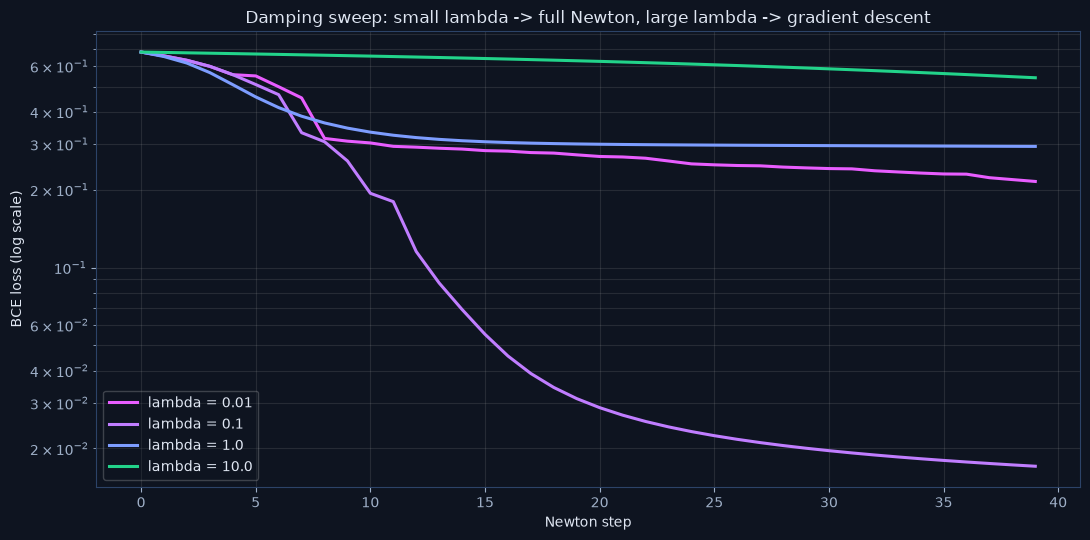

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for lam, c in zip([0.01, 0.1, 1.0, 10.0], ["#e85dff","#c07dff","#7d9dff","#22d38a"]):
    _, L = run_newton(steps=40, lr=1.0, damping=lam)
    ax.semilogy(range(len(L)), np.maximum(L,1e-12), lw=2.2, color=c,
                label=f"lambda = {lam}")
ax.set_xlabel("Newton step"); ax.set_ylabel("BCE loss (log scale)")
ax.set_title("Damping sweep: small lambda -> full Newton, large lambda -> gradient descent")
ax.grid(True, which="both", alpha=0.15); ax.legend(framealpha=0.25)
plt.tight_layout(); plt.show()

## 8 · Findings

- **Exact curvature is usable at this scale.** For a 105-parameter model the full
  $105\times105$ Hessian is formed exactly via `torch.func.hessian` every step —
  no approximations.
- **The Hessian is genuinely indefinite** on this non-convex loss (see the
  negative eigenvalues in §4), which is *why* naive Newton would diverge and why
  the damping + descent-guard + line-search machinery is necessary.
- **Second order needs far fewer steps.** Newton drives the BCE loss down in a few
  dozen steps versus hundreds for Adam/SGD, because each step already accounts for
  the local curvature instead of discovering it slowly through momentum/averaging.
- **Damping $\lambda$ is the control knob** that continuously interpolates between
  first- and second-order behaviour (§7), and simultaneously guarantees an
  invertible, positive-definite system.

**Cost caveat.** The full Hessian is $O(P^2)$ memory and its solve is $O(P^3)$.
This is why exact second-order methods are reserved for small models or replaced
by curvature *approximations* (K-FAC, Gauss–Newton, L-BFGS, Hutchinson-diagonal)
at scale. Here, keeping the model tiny let us study the **exact** mechanics with
zero approximation — which was the whole point.